In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import mysql.connector
from dotenv import load_dotenv
import os

In [2]:
load_dotenv()

connection = mysql.connector.connect(
    host=os.getenv("MYSQL_HOST"),
    user=os.getenv("MYSQL_USER"),
    password=os.getenv("MYSQL_PASSWORD"),
    database=os.getenv("MYSQL_DATABASE")
)

## Research Question 1

Which genres have the highest average popularity?

In [3]:
query = """
SELECT
    g.genre_name,
    COUNT(*) AS tracks,
    ROUND(AVG(t.popularity),2) AS average_popularity
FROM Tracks t
JOIN Genres g
    ON t.genre_id = g.genre_id
GROUP BY g.genre_name
ORDER BY average_popularity DESC;
"""

genre_df = pd.read_sql(query, connection)

genre_df.head()

/tmp/ipykernel_21928/681200633.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  genre_df = pd.read_sql(query, connection)


,genre_name,tracks,average_popularity
0,dfw rap,2,92.5
1,trap music,1,92.0
2,electropop,2,92.0
3,reggaeton,2,91.0
4,escape room,1,91.0


In [4]:
genre_df["label"] = genre_df.apply(
    lambda row: f"{row['genre_name']} ({row['tracks']})",
    axis=1
)

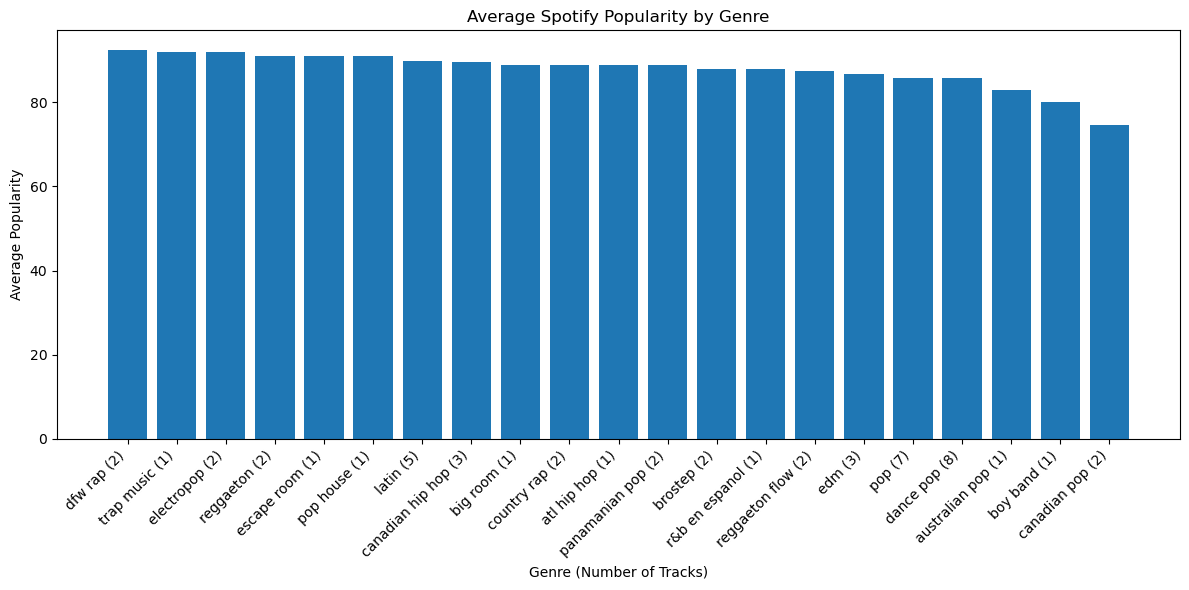

In [5]:
plt.figure(figsize=(12,6))

plt.bar(
    genre_df["label"],
    genre_df["average_popularity"]
)

plt.title("Average Spotify Popularity by Genre")
plt.xlabel("Genre (Number of Tracks)")
plt.ylabel("Average Popularity")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

Because many genres in our dataset only have one song, we will filter out genres represented by only one track.

In [6]:
query = """
SELECT
    g.genre_name,
    COUNT(*) AS tracks,
    ROUND(AVG(t.popularity),2) AS average_popularity
FROM Tracks t
JOIN Genres g
    ON t.genre_id = g.genre_id
GROUP BY g.genre_name
HAVING COUNT(*) >= 2
ORDER BY average_popularity DESC;
"""

genre2_df = pd.read_sql(query, connection)

/tmp/ipykernel_21928/1908831253.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  genre2_df = pd.read_sql(query, connection)


In [7]:
genre2_df["label"] = (
    genre2_df["genre_name"] +
    " (" +
    genre2_df["tracks"].astype(str) +
    ")"
)

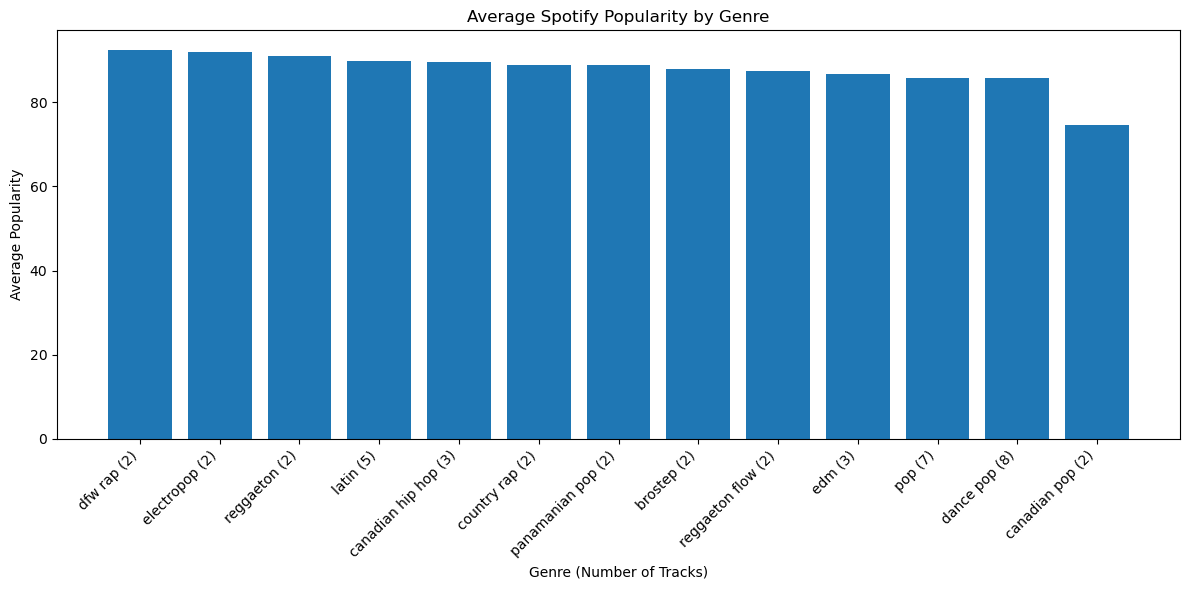

In [8]:
plt.figure(figsize=(12,6))

plt.bar(
    genre2_df["label"],
    genre2_df["average_popularity"]
)

plt.title("Average Spotify Popularity by Genre")
plt.xlabel("Genre (Number of Tracks)")
plt.ylabel("Average Popularity")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.show()

## Research Question 2

Does danceability appear to be associated with song popularity?

In [9]:
query = """
SELECT
    af.danceability,
    t.popularity
FROM Tracks t
JOIN Audio_Features af
ON t.track_id = af.track_id;
"""

dance_df = pd.read_sql(query, connection)

/tmp/ipykernel_21928/2280288057.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  dance_df = pd.read_sql(query, connection)


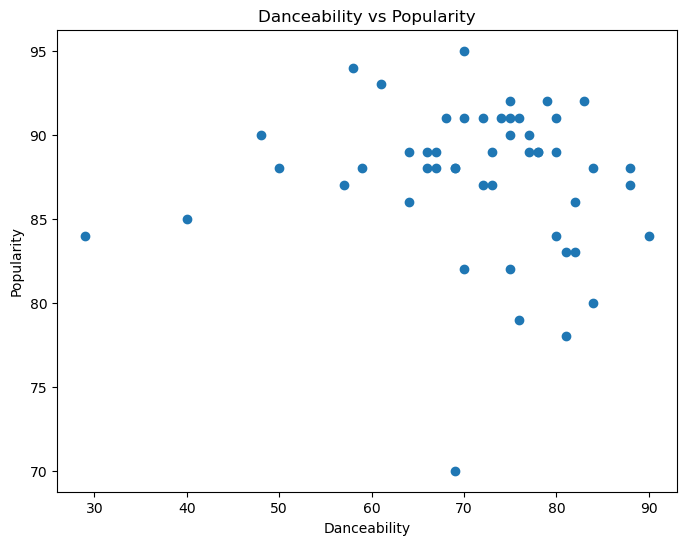

In [10]:
plt.figure(figsize=(8,6))

plt.scatter(
    dance_df["danceability"],
    dance_df["popularity"]
)

plt.title("Danceability vs Popularity")

plt.xlabel("Danceability")
plt.ylabel("Popularity")

plt.show()

## Research Question 3

Does higher energy appear to be associated with greater popularity?

In [11]:
query = """
SELECT
    af.energy,
    t.popularity
FROM Tracks t
JOIN Audio_Features af
ON t.track_id = af.track_id;
"""

energy_df = pd.read_sql(query, connection)

/tmp/ipykernel_21928/723504650.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  energy_df = pd.read_sql(query, connection)


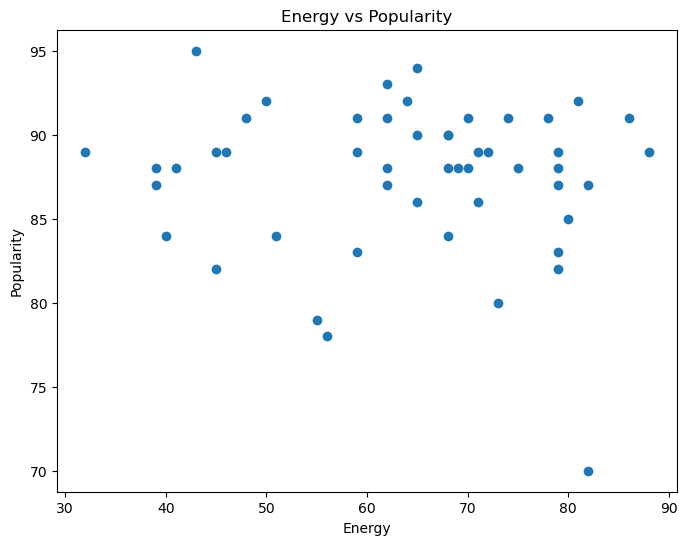

In [12]:
plt.figure(figsize=(8,6))

plt.scatter(
    energy_df["energy"],
    energy_df["popularity"]
)

plt.title("Energy vs Popularity")

plt.xlabel("Energy")
plt.ylabel("Popularity")

plt.show()

## Research Question 4

Which artists received the most Grammy nominations while also appearing in Spotify's Top 50?

In [13]:
query = """
SELECT
    a.artist_name,
    COUNT(gn.nomination_id) AS nominations
FROM Artists a
JOIN Grammy_Nominations gn
ON a.artist_id = gn.artist_id
GROUP BY a.artist_name
ORDER BY nominations DESC;
"""

grammy_df = pd.read_sql(query, connection)

/tmp/ipykernel_21928/1761390233.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  grammy_df = pd.read_sql(query, connection)


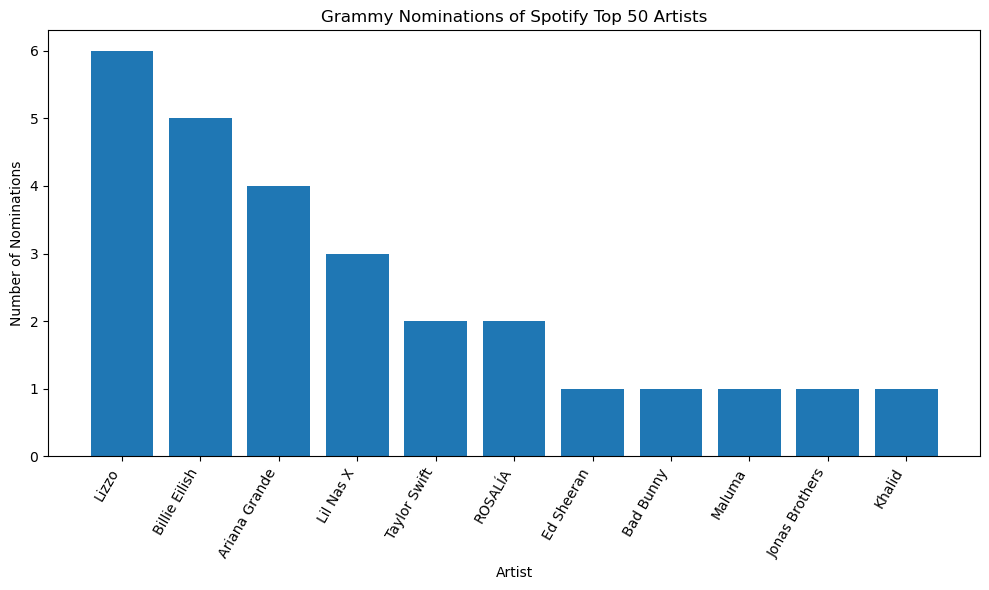

In [14]:
plt.figure(figsize=(10,6))

plt.bar(
    grammy_df["artist_name"],
    grammy_df["nominations"]
)

plt.title("Grammy Nominations of Spotify Top 50 Artists")

plt.xlabel("Artist")
plt.ylabel("Number of Nominations")

plt.xticks(rotation=60, ha="right")

plt.tight_layout()

plt.show()

## Research Question 5

Do artists with more Grammy nominations also have higher average Spotify popularity?

In [15]:
query = """
SELECT
    a.artist_name,
    COUNT(DISTINCT gn.nomination_id) AS nominations,
    ROUND(AVG(t.popularity),2) AS avg_popularity
FROM Artists a
JOIN Grammy_Nominations gn
    ON a.artist_id = gn.artist_id
JOIN Tracks t
    ON a.artist_id = t.artist_id
GROUP BY a.artist_name
ORDER BY nominations DESC, avg_popularity DESC;
"""

artist_df = pd.read_sql(query, connection)

/tmp/ipykernel_21928/2707154546.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  artist_df = pd.read_sql(query, connection)


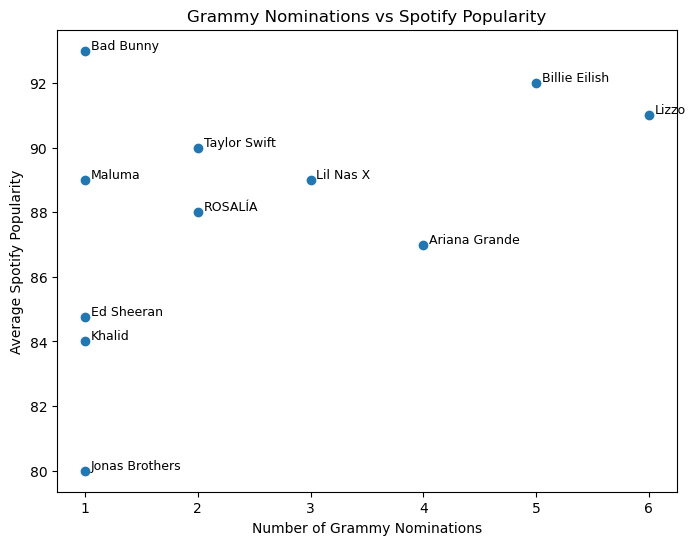

In [21]:
plt.figure(figsize=(8,6))

plt.scatter(artist_df["nominations"], artist_df["avg_popularity"])

for i, row in artist_df.iterrows():
    plt.text(
        row["nominations"] + 0.05,
        row["avg_popularity"] + 0.05,
        row["artist_name"],
        fontsize=9
    )

plt.xlabel("Number of Grammy Nominations")
plt.ylabel("Average Spotify Popularity")
plt.title("Grammy Nominations vs Spotify Popularity")
plt.show()

In [ ]:
query = """
SELECT
    ROUND(AVG(bpm),2) AS bpm,
    ROUND(AVG(energy),2) AS energy,
    ROUND(AVG(danceability),2) AS danceability,
    ROUND(AVG(acousticness),2) AS acousticness,
    ROUND(AVG(speechiness),2) AS speechiness,
    ROUND(AVG(valence),2) AS valence
FROM Audio_Features;
"""

audio_df = pd.read_sql(query, connection)

audio_df

/tmp/ipykernel_10758/1499850711.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  audio_df = pd.read_sql(query, connection)


,bpm,energy,danceability,acousticness,speechiness,valence
0,120.06,64.06,71.38,22.16,12.48,54.6


In [ ]:
audio_plot = audio_df.T.reset_index()

audio_plot.columns = ["Feature", "Average"]

audio_plot

,Feature,Average
0,bpm,120.06
1,energy,64.06
2,danceability,71.38
3,acousticness,22.16
4,speechiness,12.48
5,valence,54.60


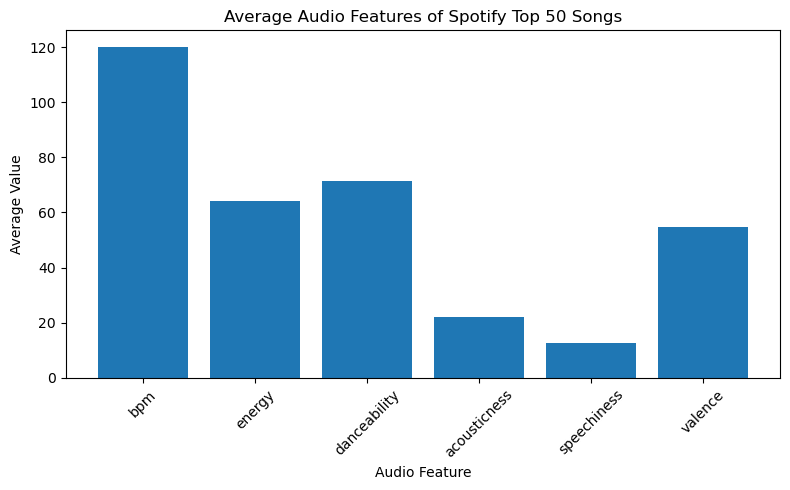

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    audio_plot["Feature"],
    audio_plot["Average"]
)

plt.title("Average Audio Features of Spotify Top 50 Songs")
plt.xlabel("Audio Feature")
plt.ylabel("Average Value")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()